# Automatische Erkennung von Katastrophenmeldungen auf Twitter

Projektarbeit - Artificial Intelligence
Kaggle Challenge: *Natural Language Processing with Disaster Tweets*


### 1. Kontext & Problemstellung

Soziale Medien wie Twitter spielen in Not- und Krisensituationen eine immer wichtigere Rolle. Durch die weitere Verbreitung von Smartphones können Augenzeugen Ereignisse wie Naturkatastophen, Brände oder Unfälle in Echtzeit melden. 

Für Hilfsorganisationen, Behörden und Nachrichtenagenturen ist jedoch schwierig automatisch zu erkennen, ob ein Tweet tatsächlich eine reale Katastrophe beschreibt oder ob Begriffe wie 'fire', 'flood' oder explosion lediglich metaphorisch verwendet werden. 

Da täglich grosse Mengen an Tweets erzeugt werden, ist eine manuelle Überwachung nicht skalierbar. Aus diesem Grund besteht ein grosses Interesse an automatisierten Systemen, die relevante Katastrophen zuverlässig identifizieren können

### 2. Fragestellung 

Die zentrale Fragestellung dieses Projektes lautet: 

Lassen sich Tweets mithilfe von Natrual Language Processing (NLP) und Machine-Learning-Verfahren zuverlässig in 'reale Katastrophe' und 'keine Katastrophe' klassifizieren?

### 3. Zielsetzung & Evaluationsmetrik

Ziel dieses Projekts ist es, ein KLassifikationsmodell zu entwicklen, das Tweets korrekt danach einordnet, ob sie sich auf reale Katastrophen beziehen oder nicht. 

Ale Evaluationsmetrik wird der F1-Score verwendet. 
Der Datensatz weist eine unausgeglichene Klassenverteilung auf, weshalb die reine Accuary keine geeignete Kennzahl darstellt. 

Der F1-Score kombiniert Precision und Recall und erlaubt somit eine ausgewogene Bewertung zwischen Fehlalarm (Fale Positives) und übersehenen Katastrophenmeldungen (Fale Negatives). 

### 4. Datensatz 
Der verwendete Datensatz stammt aus der Kaggle-Challenge 'Natrual Language Processing with Diaster Tweets'. 

Jeder Eintrag entspricht ein Tweet und enthält under anderem:
-den Text des Tweets
-optionale Zusatzinformationen wie Keyword oder Location 
-ein lable ('target'), das angibt ob es sich um eine reale Katastrophe handelt (1) oder nicht (0)

Der Datensatz ist für eine binäre Textklassifikation ausgelegt.

### 5. Erste Exploration der Daten

Im folgenden Abschnitt werden die Struktur und grundlegende Eigenschaften des Datensatzes untersucht, um ein besseres Verständnis der Datenbasis für die Modellierung zu erhalten.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#daten laden
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [5]:
#Überblick über den Trainingsdatensatz
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [6]:
#Klassenverteilung 
target_counts = train['target'].value_counts()
target_counts

target
0    4342
1    3271
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

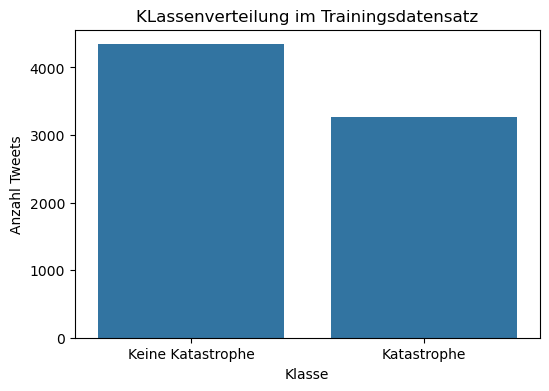

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)
plt.xticks([0, 1], ['Keine Katastrophe', 'Katastrophe'])
plt.ylabel('Anzahl Tweets')
plt.xlabel('Klasse')
plt.title('KLassenverteilung im Trainingsdatensatz')
plt.show

Die Klassenverteilung ist nicht vollständig ausgeglichen. 
Es gibt leicht mehr Tweets ohne reale Katastrophe als mit Katastrophe. 
Aus diesem Grund ist die Accuarcy als alleinige Metrik nicht geeignet, weshalb im weiteren Verlauf der F1-Score verwendet wird

In [8]:
#Textlänge (Anzahl Zeichen)
train['text_length'] = train['text'].apply(len)
train[['text', 'text_length']].head()

,text,text_length
0,Our Deeds are the Reason of this #earthquake M...,69
1,Forest fire near La Ronge Sask. Canada,38
2,All residents asked to 'shelter in place' are ...,133
3,"13,000 people receive #wildfires evacuation or...",65
4,Just got sent this photo from Ruby #Alaska as ...,88


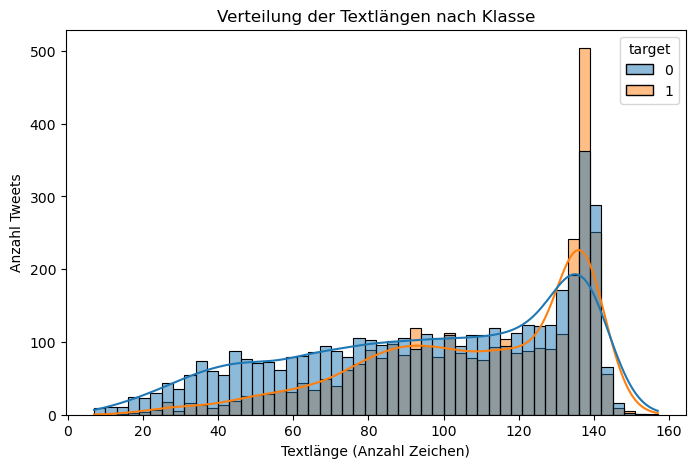

In [9]:
#Textlänge nach Klasse vergleichen 

plt.figure(figsize=(8, 5))
sns.histplot(
    data=train,
    x='text_length',
    hue='target',
    bins = 50,
    kde = True
)
plt.xlabel('Textlänge (Anzahl Zeichen)')
plt.ylabel('Anzahl Tweets')
plt.title('Verteilung der Textlängen nach Klasse')
plt.show()

In [10]:
#Durchschnittliche Textlänge pro Klasse
train.groupby('target')['text_length'].mean()

target
0     95.706817
1    108.113421
Name: text_length, dtype: float64

Tweets, die reale Katastrophen beschreiben, sind im Durchscnitt etwas länger als Tweets ohne Katastrophenbezug. 
Dies deutet darauf hin, dass zustätzliche Kontextinformationen eine Rolle spielen können, was für komplexere Modelle relevant sein könnte.

In [11]:
# Anteil fehlende Werte pro Spalte
train.isna().mean()

id             0.000000
keyword        0.008013
location       0.332720
text           0.000000
target         0.000000
text_length    0.000000
dtype: float64

Die Spalte 'Keyword' und 'Location' enthalten viele fehlende Werte. Im weiteren Verlauf wird der Fokus daher primär auf den Textinhalt der Tweets gelegt. 
Optionale Zusatzinformationen könnten später seperat untersucht werden, werden jedoch für die Basleine nicht berücksichtigt. 

### 6. Fazit der explorative Datenanalyse

Die explorative Analyse zeigt, dass: 
-ein moderates Klassengleichgewicht vorliegt
-Tweets kurze, aber informative Texte enthalten 
-der Textinhalt die zentrale Informationsquelle darstellt

Die Erkenntnisse bilden die Grundlage für die anschliessende Baseline-Modellierung mit TF-IDF und logistische Regressionsmodellen.

### 7. Baseline-Modell
Basierend auf den Erkenntnissen aus der explorativen Datenanalyse wird im folgenden Abschnitt ein Baseline-Modell zur Textklassifikation implementiert.

Das Ziel der Baseline ist es, eine einfache und gut interpretierbare Referenz zu schaffen, anhand derer komplexere Modelle spärter verglichen werden können.

Als Baseline wird ein klassischer NLP-Ansatz bestehend aus TF-IDF (Term Frequency - Inverse Document Frequency) und einer logistischen Regression verwendet. 

In [12]:
#Imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
#Features und Zielvariablen definieren 

X = train['text']
y = train['target']

#Trainings- und Validierungsdaten aufteilen
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify = y
)

#stratifiy: Erhält die Klassenverteilung in Train & Validation 

In [14]:
# Pipeline: TF-IDF Vektorisierung + Logistische Regression 
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 10000,
        ngram_range = (1, 2),
        stop_words = 'english'
    )),
    ('clf', LogisticRegression(
        max_iter = 1000,
        solver = 'liblinear'
    ))
])

In [15]:
#Modell trainieren 
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000, solver='liblinear'))])

In [16]:
#Vorhersage erzeugen 
y_pred = baseline_model.predict(X_val)

In [17]:
#Precision, Recall, F1-Score
print(classification_report(y_val, y_pred, target_names=[
    'Keine Katastrophe',
    'Katastrophe'
]))

                   precision    recall  f1-score   support

Keine Katastrophe       0.80      0.90      0.85       869
      Katastrophe       0.84      0.70      0.76       654

         accuracy                           0.81      1523
        macro avg       0.82      0.80      0.81      1523
     weighted avg       0.82      0.81      0.81      1523



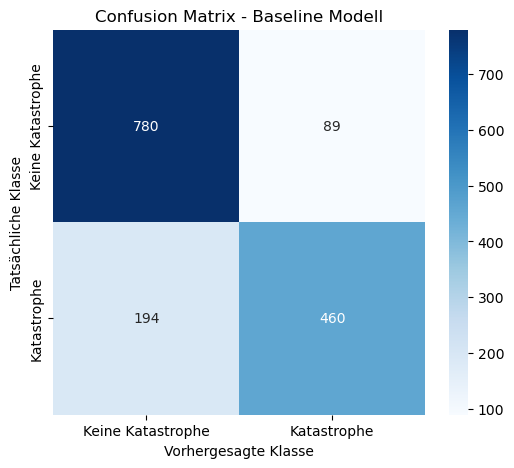

In [18]:
#Confusionsmatrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = ['Keine Katastrophe', 'Katastrophe'],
    yticklabels = ['Keine Katastrophe', 'Katastrophe']
)
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.title('Confusion Matrix - Baseline Modell')
plt.show()


### 8. Evaluation der Baseline

Das Baseline-Modell bestehend aus TF-IDF und logistischer Regression erreicht eine Accuracy von rund 80% sowie einen gewichteten F1-Score von 0.81. 
Die zeigt, dass bereits mit einem einfachen, wortbasierten Ansatz eine solide Klassifikationsleitung erzielt werden kann. 

Für die Klasse 'Keine Katastrophen' wird ein hoher Recall von 0.90 erreicht, was bedeutet, dass Tweets ohne realen Katastrophenbezug zuverlässig erkennt werden. Gleichzeitig liegt die Precision dieser Klasse bei 0.80, was auf vereinzelte Fehlalarme hinweist. 

Für die Klasse 'Katastrophe' ergibt sich eine Precision von 0.84 und ein Recall von 0.70. Das Midell erkennt somit einen Grossteil der tatsächlichen Katastrophen-Tweets korrekt, übersieht jedoch einen relevanten Anteil (False Negatives).

Die Confusion Matrix zeigt, dass inebesondere reale Katastrophenmeldungen teilweise fälschlicherweise als 'Keine Katastrophe' klassifiziert werden. Die deutet darauf hin, dass rein wortbasierte Merkmale bei impliziten oder kontextabhängige Formulierungen an ihre Grenzen stossen.

### 9. Zusammenfassung des Baseline-Modells
Mit dem TF-IDF + LogReg Ansatz wurde eine einfache, effiziente und gut interpretierbare Baseline für die Klassifikation von Disaster Tweets implementiert. 

Das Modell erzeilt eine solide Gesamtleistung, zeigt jedoch insbesondere bei der Erkennung realer Katastrophen Einschränkungen im Recall. 
Diese Beobachtung ist kritisch, da übersehene Katastrophenmeldungen in realen Anwendungsszenarien problematisch sein können. 

Die Baseline dient daher als klar definierter Referenzpunkt für den Einsatz komplexere Modelle, die semantische und kontextuelle Zusammenhänge besser erfassen können. 

### 10. Fehleranalyse und Zusatzanalyse

Aufbauend auf den Resultaten der Baseline-Modellierung wird im folgenden Abschnitt eine detailierte Fehleranalyse durchgeführt. 

Ziel ist es, typische Fehlklassifikationen systematisch zu untersuchen und besser zu verstehen, unter welchen Bedingungen das Modell scheitert. Diese Analyse dient als Grundlage für gezielte Modellverbesserungen.

#### 10.1 Definition der Fehlertypen 

Für die Fehleranalyse werden folgende Fehlklassifikationen betrachtet: 

- **False Positives (FP):** Tweets, die fälschlicherweise als Katastrophe klassifiziert wurden.
- **False Negatives (FN:** Tweets, die eine reale Katastrophe beschreiben, jedoch als 'keine Katastrophe' klassifiziert wurden.

Insbesondere False Negatives sind kritisch, da reale Katastrophenmeldungen nicht erkennt wurden

In [20]:
# Validierungsdaten inkl. Vorhersagen zusammenführen

val_df = pd.DataFrame({
    'text' : X_val,
    'true_label' : y_val,
    'pred_label' : y_pred
})

#Fehlertyp bestimmen
val_df['error_type'] = 'Correct'
val_df.loc[(val_df.true_label == 0) & (val_df.pred_label == 1), 'error_type'] = 'False Positives'
val_df.loc[(val_df.true_label == 1) & (val_df.pred_label == 0), 'error_type'] = 'False Negatives'

val_df.head()

,text,true_label,pred_label,error_type
4863,@TheEconomist Step one: get that mass murderer...,0,1,False Positives
1370,Ted Cruz fires back at Jeb &amp; Bush: ÛÏWe l...,0,0,Correct
3521,How ÛÏLittle BoyÛ Affected the People In Hi...,1,1,Correct
178,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...,0,0,Correct
5859,'Cause you play me like a symphony play me til...,0,0,Correct


In [21]:
val_df['error_type'].value_counts()

error_type
Correct            1240
False Negatives     194
False Positives      89
Name: count, dtype: int64

In [26]:
#Zufällige Beispiele für False Positives

fp_examples = val_df[val_df['error_type'] == 'False Positives']. sample(5, random_state=42)

fp_examples[['text']]

,text
4327,REVEALED: Everton hijack United bid for 14-year-old WONDERKID! - http://t.co/nb1E7mNcE5
6504,10 Ways To Survive and Escape Martial Law | World http://t.co/BiuEY7bUtS http://t.co/JWQYbe4ep1
1541,Google Alert: Emergency units simulate a chemical explosion at NU http://t.co/NDgpWYxu6H
2951,So today I fell off a rock scraped my whole butt and nearly drowned #summer2k15
6703,L B #Oklahoma #Thunder DURANT NBA ADIDAS OKLAHOMA CITY THUNDER YOUTH LARGE SWINGMAN JERSEY RETAIL $75 #NBA #Durant http://t.co/T81oayjoWC


In [25]:
pd.set_option("display.max_colwidth", None)


In [27]:
#Zufällige Beispiele für False Negatives

fn_examples = val_df[val_df['error_type'] == 'False Negatives']. sample(5, random_state=42)

fn_examples[['text']]

,text
5538,Some of worst radiation exposure from Fukushima meltdown happened 47km northwest-Proof that small emergency planning zones donÛªt cut it
6647,@SwiftyCommissh @TaoistInsight @ImmortalTech Some jewish ppl agree tht Israel is a bully nd a terrorist state killin palestine kids nd women
598,[JAX Biz Journal] FedEx stops shipping potential bioterror pathogens http://t.co/R33nCvjovC
7489,@GeorgeFoster72 and The Wreck of the Edmund Fitzgerald
5507,Reddit's new content policy goes into effect many horrible subreddits banned or quarantined http://t.co/ZsXqbdUzBN http://t.co/6NCfjXPLOY


#### 10.2 Intepretation der Fehlklassifikation 

Die Analyse der False Positives zeigt, dass das Modell häufig auf einzelne stark gewichtete Schlüsselbegriffe reagiert, ohne den inhaltlichen Kontext des Tweets korrekt zu erfassen. 

Beispiele hierfür sind Tweets, die Begriffe wie 'emergency', 'explosion' oder 'martial law' enthalten, jedoch kein realen Katastrophenbezug haben, sondern sich auf Simulationen, Medienberichte, Sportereignisse oder reisserische Überschriften beziehen. Der TF-IDF-Ansatz interpretiert diese Begriffe isoliert und stuft den Tweet daher fälschlicherweise als Katastrophe ein. 

Die False Negatives verdeutlichen eine andere Schwäche des Modells. 
Mehrere dieser Tweets beschreiben reale, teils schwerwiegende Ereignisse (z.B. Fukushima-Strahlung, Bioterror-Gefahr oder politische Gewalt), verwenden jedoch keine klaren oder häufigen Katastrophen-Schlüsselwörter. Stattdessen sind die Beschreibungen komplex, indirekt oder stark kontextabhängig. 

Diese Beobachtungen zeigen, dass das Baseline-Modell insbesondere dann scheitert, wenn Bedeutung nicht durch einzelne Wörter, sondern durch den Gesamtzusammenhang des Textes entsteht. 

Damit wird eine zentrale Limitation des TF-IDF-Ansatzes sichtbar: 
Semantische Beziehungen, Ironie, indirekte Beschreibungen und KOntextinformationen können nur unzureichend abgebildet werden. 

In [28]:
#Textlänge berechnen 
val_df['text_length'] = val_df['text'].apply(len)

#Durchschnittliche Textlänge nach Fehlertyp
val_df.groupby('error_type')['text_length'].mean()

error_type
Correct            101.016129
False Negatives    100.474227
False Positives    100.247191
Name: text_length, dtype: float64

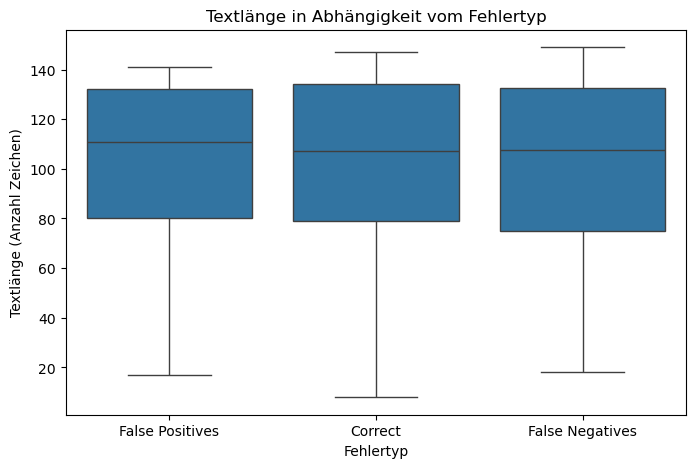

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(
    data = val_df, 
    x = 'error_type',
    y = 'text_length'
)
plt.xlabel('Fehlertyp')
plt.ylabel('Textlänge (Anzahl Zeichen)')
plt.title('Textlänge in Abhängigkeit vom Fehlertyp')
plt.show()

#### 10.3 Zusatzanalyse: Textlänge vs. Modellfehler

Die Boxplot-Analyse zeigt, dass sich die Textlängen der drei Gruppen (False Positives, korrekt klassifizierte Tweets und False Negatives) stark Überlappen. 

Weder der Medien noch die Streuung der Textlängen unterscheiden sich signifikant zwischen den Fehlertypen. Insbesondere sind False Negative Tweets nicht systematisch länger als korrekt klassifizierte Tweets. 

Dies deutet darauf hin, dass die Textlänge allein keinen entscheidenden Einfluss aif die Fehler des Modells hat. Die beobachteten Fehlklassifikationen lassen sich somit nicht durch die Länge der Tweets erklären, sondern vielmehr durch inhaltliche und semantische Aspekte. 

Das Ergebnis unterstreicht, dass nicht die Menge des Textes, sondern die Art der sprachlichen Formulierung und der Kontext entscheidend für die Modellperformance sind. 

#### 10.4 Diskussion der Resultate

Die Fehleranalyse zeigt, dass die Schwächen des Baseline-Modells nicht auf oberflächliche Eigenschaften wie die Textlänge zurückzuführen sind, sondern auf inhaltliche und semantische Limitationen. 

False Positives entstehen vor allem dann, wenn katastrophenassozierte Schlüsselwörter ausserhalb eines realen Erreigniskontexts verwendet werden. 
False Negatives treten hingegen häufig bei indirekten, komplexen oder kontextanhängigen Beschreibungen realer Ereignisse auf. 

Die Zusatzanalyse zur Textlänge bestätigt, dass strukturelle Merkmale der Tweets nur eine untergeordnete Rolle spielen, Entscheidend ist vielmehr, ob das Modell in der Lage ist, Bedeutung über einzelne Wörter hinaus zu erfassen. 

Damit wird deutlich, dass rein wortbasierte Ansätze wie TF-IDF grundlegende Grenzen besitzen, wenn semantisches Verständnis erforderlich ist.

### 11. Fazit der Fehleranalyse

Die detaillierte Fehleranalyse zeigt, dass das Baseline-Modell systematische Schäwchen bei der Interpretation von Kontext und Bedeutung aufweise. 

Während einzelne Schlüsselbegriffe zuverlässig erkannt werden, scheitert das Modell bei indirekten Formulierungen, Ironie und komplexen sprachlichen Zusammenhängen. Die Zusatzanalyse bestätigt zudem, dass diese Fehler nicht durch einfach struktuelle Merkmale wie die Textlänge erklärt werden können. 

Diese Erkenntnisse leifern eine klare Motivation für den Einsatz leistungsfähigerer Modelle, die sematische Beziehungen besser erfasen können. 
Im nächsten Abschnitt wird daher ein neuronales Netz zur Textklassifikation eingesetzt, um diese Limitationen gezielt anzugehen.